# **Chapter 10 - Recurrent Neural Networks**



Recurrent Neural Networks (RNNs) are a class of neural networks designed to recognize patterns in sequences of data, such as text, speech, or time series. Unlike traditional feedforward neural networks, RNNs have 'memory'—they can use information from previous steps in a sequence to influence the processing of the current step.

Key characteristics:

*   **Sequential Data Processing:** Ideal for tasks where the order of input matters.
*   **Internal Memory:** They maintain a hidden state that captures information about the sequence processed so far.
*   **Parameter Sharing:** The same weights are used across all time steps, making them efficient for varying sequence lengths.
*   **Applications:** Widely used in natural language processing (e.g., language modeling, machine translation, sentiment analysis), speech recognition, and more.


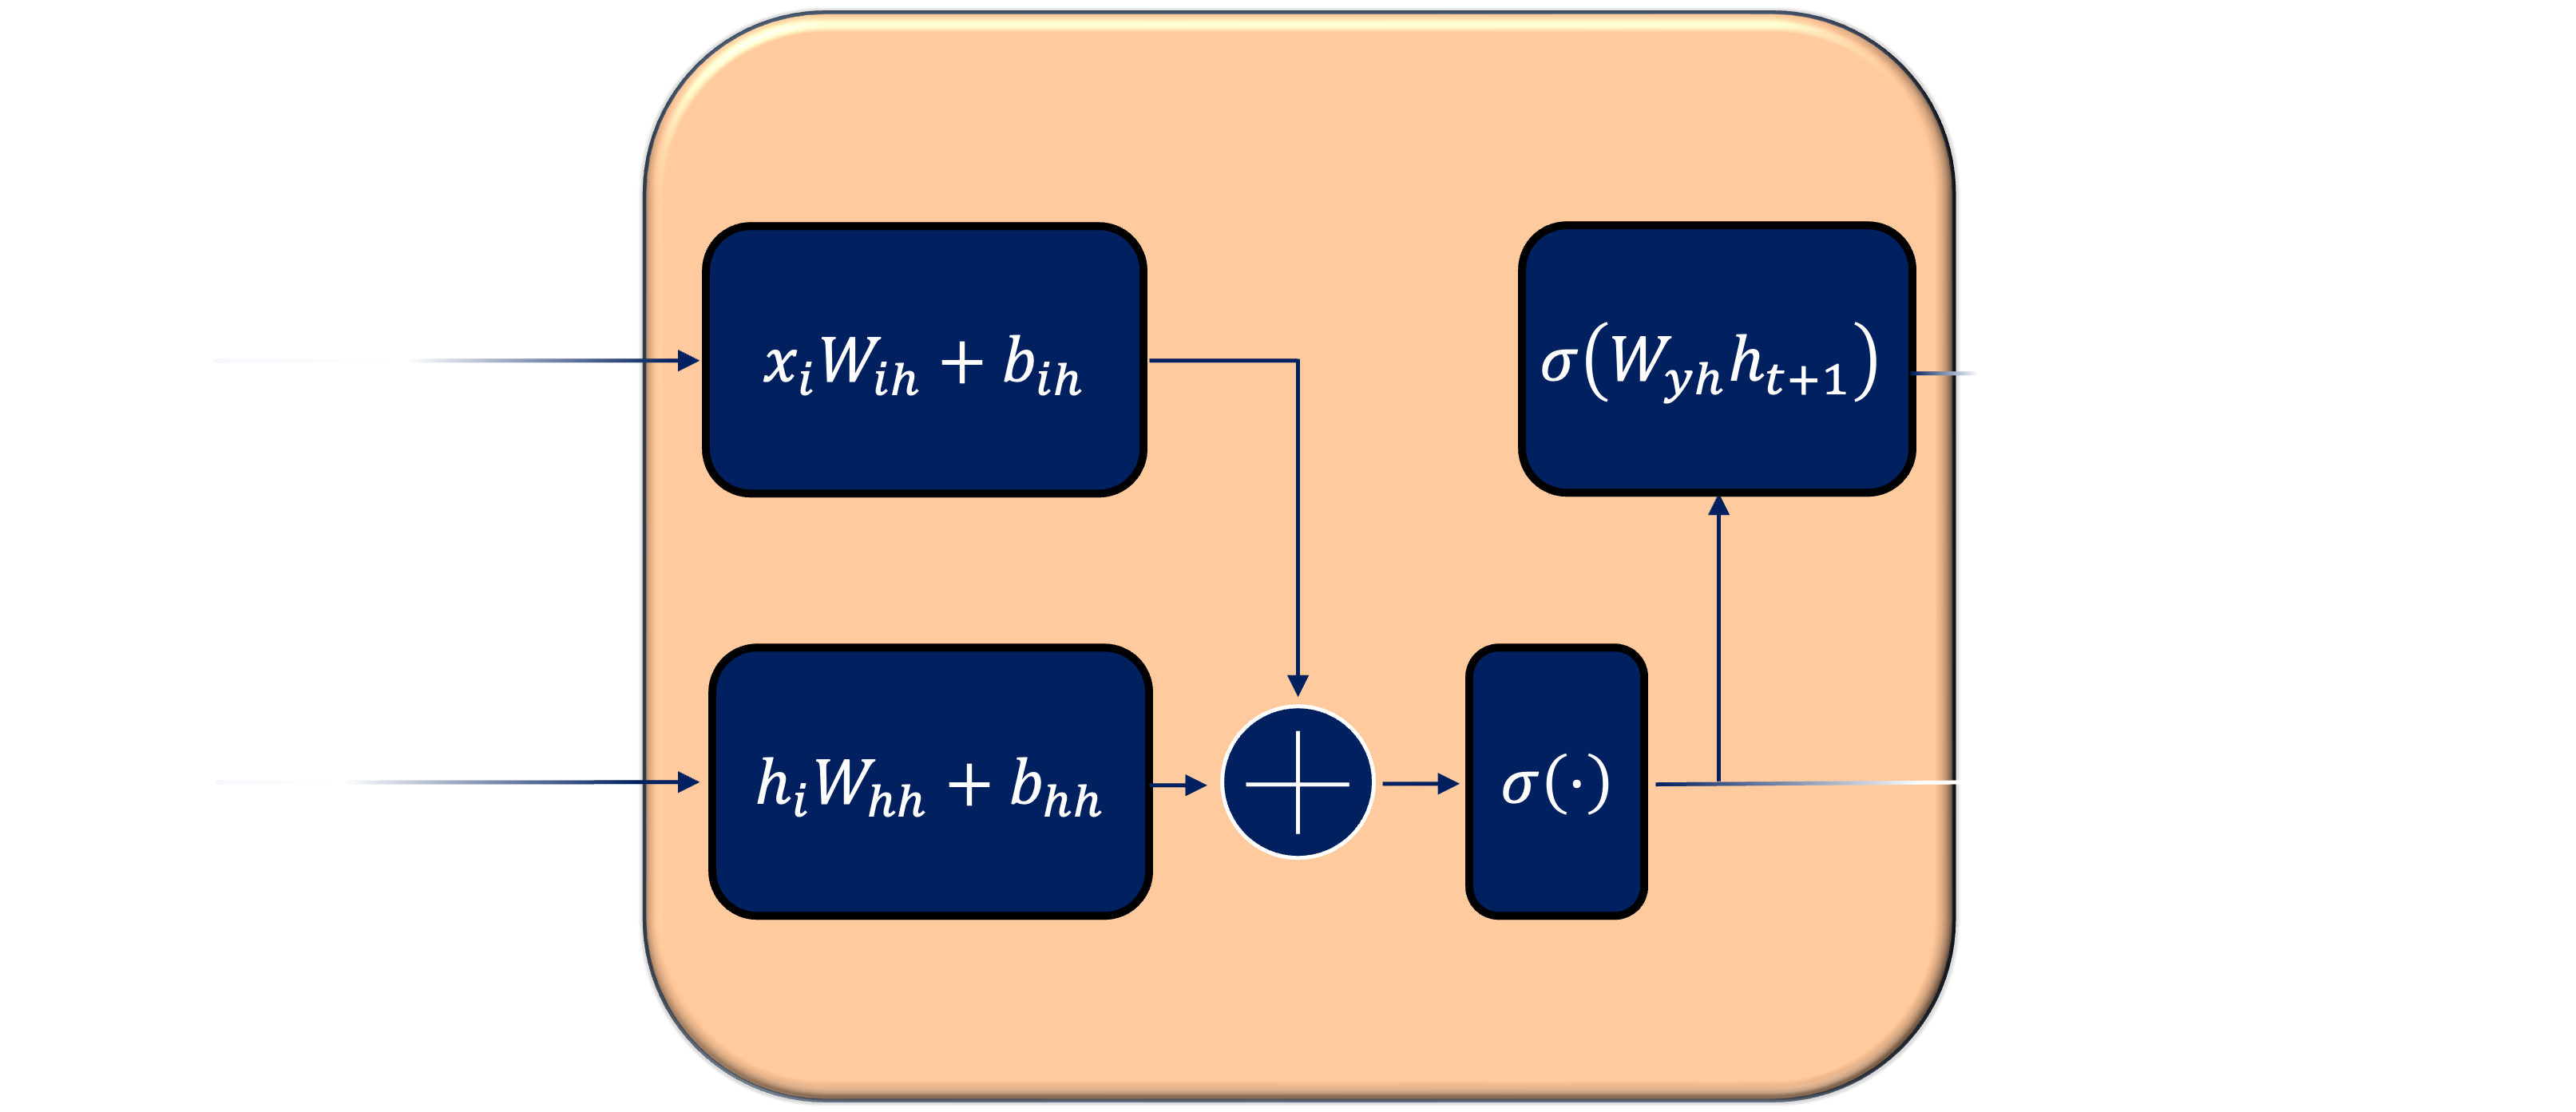

### **IMDB Movie Review Sentiment Classification Dataset**

This notebook utilizes the IMDB movie review dataset, a popular benchmark for sentiment analysis tasks. Here's a brief overview:

*   **Purpose:** The dataset is designed for binary sentiment classification, meaning the goal is to classify movie reviews as either positive or negative.
*   **Data:** It consists of 50,000 highly polarized movie reviews from the Internet Movie Database (IMDB), split into 25,000 reviews for training and 25,000 for testing.
*   **Preprocessing:** Each review has been preprocessed and encoded as a sequence of integers, where each integer represents a specific word. Only the top 10,000 most frequent words are retained, and reviews are padded to a uniform length (e.g., 256 words) for consistent input to neural networks.
*   **Labels:** Each review is associated with a binary label:
    *   `0`: Indicates a **negative** sentiment.
    *   `1`: Indicates a **positive** sentiment.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

# Load the IMDB dataset
# num_words=10000 keeps the top 10,000 most frequently occurring words
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print(f"Training sequences: {len(train_data)}")
print(f"Test sequences: {len(test_data)}")

Training sequences: 25000
Test sequences: 25000


In [2]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader


# Convert numpy arrays of lists to lists of PyTorch tensors
# This creates individual tensors for each sequence
train_data_tensors = [torch.tensor(seq, dtype=torch.long) for seq in train_data]
train_labels_tensor = torch.tensor(train_labels, dtype=torch.float)

test_data_tensors = [torch.tensor(seq, dtype=torch.long) for seq in test_data]
test_labels_tensor = torch.tensor(test_labels, dtype=torch.float)


# The actual dataset will be a list of (sequence_tensor, label_tensor)
train_dataset_list = list(zip(train_data_tensors, train_labels_tensor))
test_dataset_list = list(zip(test_data_tensors, test_labels_tensor))

BOLD = '\033[1m'
END = '\033[0m'

print(f"Number of samples in the dataset:{END} {BOLD}{len(train_dataset_list)}{END}")
print("----------------------------")
for i, elem in enumerate(train_dataset_list[:10]):
    # Making the label bold and the value normal
    print(f"| Length of sample {i} | {BOLD}{len(elem[0])}{END} |")


Number of samples in the dataset: 25000
----------------------------
| Length of sample 0 | 218 |
| Length of sample 1 | 189 |
| Length of sample 2 | 141 |
| Length of sample 3 | 550 |
| Length of sample 4 | 147 |
| Length of sample 5 | 43 |
| Length of sample 6 | 123 |
| Length of sample 7 | 562 |
| Length of sample 8 | 233 |
| Length of sample 9 | 130 |


In [28]:
## HYPERPARAMETERS:

# Limit the training set
num_train_samples = 300000

# Batch Size
batch_size = 32

#Learning rate
lr = 0.001

# length of each sample
segment_length = 15

# device
device = "cuda" if torch.cuda.is_available() else "cpu"

### **Data Preparation for Next-Word Prediction**

To prepare the IMDB movie review data for a next-word prediction task, we are performing the following steps:

1.  **Sliding Window Segmentation:** Each original review (sequence of words) is processed using a sliding window of 15 words. This means for a sequence `[w1, w2, w3, ..., wn]`, we generate multiple 15-word segments like `[w1, ..., w15]`, `[w2, ..., w16]`, and so on.
2.  **Input and Label Definition:** For each 15-word segment, the first 14 words (`[w_i, ..., w_{i+13}]`) are used as the input sequence to the model, and the 15th word (`w_{i+14}`) is designated as the label (the word to be predicted).
3.  **Minimum Length Filtering:** Any original review that is shorter than 15 words is discarded, as it cannot form a complete 15-word segment.
4.  **Special Token and 'br' Filtering:** We further refine the dataset by excluding any 15-word segments (input + label) that contain special tokens (e.g., unknown words, padding, start-of-sequence markers) or the HTML break tag 'br'. This ensures cleaner, more meaningful sequences for training.


This process creates a semi-supervised learning task where the model learns to predict the next word given the preceding 14 words.

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.datasets import imdb # Import imdb to get word_index



# Get the word index to find the index for 'br'
word_index = imdb.get_word_index()
br_word_idx = word_index.get('br', None) # Get index for 'br', default to None if not found

def create_fixed_length_segments(data_list, segment_length=15, ds_length=50000):
    new_data = []
    new_labels = []
    for seq_tensor, original_label_tensor in data_list:
        # Stop if we've collected enough samples
        if len(new_data) >= ds_length:
            break

        sequence = seq_tensor.tolist() # Convert tensor to list for easier slicing

        if len(sequence) < segment_length:
            continue # Drop sequences shorter than segment_length

        # Apply sliding window
        for i in range(len(sequence) - segment_length + 1):
            # Stop if we've collected enough samples
            if len(new_data) >= ds_length:
                break

            segment = sequence[i : i + segment_length]

            # Check for (br_word_idx + 3) in segment, as indices are shifted
            if any(word_idx < 4 for word_idx in segment) or \
               (br_word_idx is not None and (br_word_idx + 3) in segment):
                continue

            # The label is now the 15th word (for last word prediction)
            label = segment[-1]
            new_data.append(torch.tensor(segment[:-1], dtype=torch.long))
            new_labels.append(torch.tensor(label, dtype=torch.long))
    return new_data, new_labels

# Create 15-word segments for training data
train_segments_data, train_segments_labels = create_fixed_length_segments(train_dataset_list, segment_length=segment_length, ds_length=num_train_samples)


train_segments_data = train_segments_data[:num_train_samples]
train_segments_labels = train_segments_labels[:num_train_samples]

# Convert lists of tensors to single tensors for TensorDataset
train_segments_tensor = torch.stack(train_segments_data)
train_segments_labels_tensor = torch.stack(train_segments_labels)

# Create new TensorDatasets and DataLoaders


train_dataset_15_words = TensorDataset(train_segments_tensor, train_segments_labels_tensor)

train_loader_15_words = DataLoader(train_dataset_15_words, shuffle=True, batch_size=batch_size)


print(f"Number of 15-word training samples: {len(train_dataset_15_words)}")

# Example of one 15-word batch
example_batch_data_15_words, example_batch_labels_15_words = next(iter(train_loader_15_words))
print(f"\nShape of example 15-word batch data: {example_batch_data_15_words.shape}")
print(f"Shape of example 15-word batch labels: {example_batch_labels_15_words.shape}")

Number of 15-word training samples: 300000

Shape of example 15-word batch data: torch.Size([32, 14])
Shape of example 15-word batch labels: torch.Size([32])


In [6]:
import random
from tensorflow.keras.datasets import imdb

# Get the word index and create a reverse mapping
# This is crucial for decoding the words back into text.
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_sequence(sequence_tensor):
    decoded_words = []
    for word_idx in sequence_tensor.tolist():
        if word_idx == 0: # Padding token
            decoded_words.append('')
        elif word_idx < 4: # Special tokens (1: start, 2: unknown, 3: unused)
            decoded_words.append('?')
        else:
            decoded_words.append(reverse_word_index.get(word_idx - 3, '?'))
    return ' '.join(decoded_words).strip()

print("\n--- Five Random 15-Word Samples from Training Data ---\n")
num_samples_to_show = 5

# Get a list of indices to sample from the dataset
all_indices = list(range(len(train_dataset_15_words)))
sentences_indices = random.sample(all_indices, num_samples_to_show)
sentences_indices = [100,101,102,103,104]

for i, idx in enumerate(sentences_indices):
    segment_tensor, label_word_idx_tensor = train_dataset_15_words[idx]

    # Decode the 15-word segment
    decoded_segment = decode_sequence(segment_tensor)

    # Decode the label (which is the 15th word)
    label_word_idx = label_word_idx_tensor.item()
    decoded_label_word = reverse_word_index.get(label_word_idx - 3, '?')

    print(f"Sample {i+1}:")
    print(f"  Sentence: \"{decoded_segment}\"")
    print(f"  Predicted word (label): \"{decoded_label_word}\"")
    print("--------------------------------------------------")



--- Five Random 15-Word Samples from Training Data ---

Sample 1:
  Sentence: "children are amazing and should be praised for what they have done don't you"
  Predicted word (label): "think"
--------------------------------------------------
Sample 2:
  Sentence: "are amazing and should be praised for what they have done don't you think"
  Predicted word (label): "the"
--------------------------------------------------
Sample 3:
  Sentence: "amazing and should be praised for what they have done don't you think the"
  Predicted word (label): "whole"
--------------------------------------------------
Sample 4:
  Sentence: "and should be praised for what they have done don't you think the whole"
  Predicted word (label): "story"
--------------------------------------------------
Sample 5:
  Sentence: "should be praised for what they have done don't you think the whole story"
  Predicted word (label): "was"
--------------------------------------------------


### **Word Embeddings: Bridging Integers and Neural Networks**

As we have seen, our dataset represents words as integers (e.g., `[14, 22, 16, ...]`). While these integers provide a unique identifier for each word, they don't inherently carry any semantic meaning or relationship between words. A neural network, especially Recurrent Neural Networks (RNNs), cannot effectively learn from these raw integer IDs.

This is where **Word Embeddings** come into play. An embedding layer serves as a crucial first step in most natural language processing (NLP) models. Its primary function is to transform these discrete integer word IDs into dense, continuous-valued vectors (also known as 'embeddings').

**Key aspects of Word Embeddings:**

*   **Dimensionality Reduction:** Instead of a sparse one-hot encoding (which can be very high-dimensional), embeddings map words to a lower-dimensional space (e.g., 128 or 256 dimensions).
*   **Semantic Representation:** Words with similar meanings or that appear in similar contexts will have similar embedding vectors. This allows the model to generalize and understand relationships between words.
*   **Trainable Parameters:** The embedding vectors themselves are usually learned during the training process of the neural network. The network adjusts these vectors to optimize performance on the given task (e.g., next-word prediction).

Therefore, before feeding our sequences of integers into an RNN, an embedding layer will convert each integer (word ID) into its corresponding dense vector representation, providing a rich input for the subsequent recurrent layers to process.

In [7]:
## Example of train sample
train_dataset_15_words[0]

(tensor([  14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458, 4468,   66,
         3941,    4]),
 tensor(173))

## **RNN Model**

**Architecture:**

Input to Output Flow for Next-Word Prediction

This diagram illustrates how a sequence of word indices flows through the defined RNN model to predict the next word:


**Explanation of each step:**

*   **Input (Batch Size, Sequence Length):** The model receives a batch of input sequences, where each sequence consists of 9 word indices (integers).
*   **Embedding Layer:** This layer takes each word index and converts it into a dense vector (embedding). Words with similar meanings tend to have similar embedding vectors. This layer is learnable.
*   **Embedded Vectors (Batch Size, Sequence Length, Embedding Dim):** The output of the embedding layer is a 3D tensor where `Embedding Dim` is the size of each word's vector representation.
*   **RNN Layer:** The Recurrent Neural Network processes the sequence of embedded vectors one by one, maintaining an internal 'hidden state' that captures information from previous words. For this model, we are using a basic `nn.RNN`.
*   **RNN Output (Batch Size, Sequence Length, Hidden Size):** The RNN layer outputs a hidden state for each word in the input sequence. `Hidden Size` is the dimensionality of the RNN's internal state.
*   **Extract Last Time Step Output (Batch Size, Hidden Size):** For predicting the *next* word given a sequence, we primarily use the hidden state corresponding to the last word of the input sequence. This hidden state summarizes the context of the entire input sequence.
*   **Linear Layer:** A fully connected (dense) layer takes the last hidden state from the RNN and transforms it into a vector of scores, one for each word in the entire vocabulary.
*   **Output: Predicted Word Probabilities (Batch Size, Vocabulary Size):** This final output represents the model's prediction for the next word. Typically, a softmax function would be applied (often implicitly by the loss function) to convert these scores into probabilities across the vocabulary.

### **The Encoder-Decoder Architecture**

This implementation utilizes a Sequence-to-Sequence (Seq2Seq) framework to model temporal dependencies.

The **Encoder** processes the input sequence and compresses the linguistic features into a fixed-size latent representation, known as the Context Vector. This vector captures the cumulative hidden state of the sequence.

Subsequently, the **Decoder** is initialized with this state to compute the probability distribution of the succeeding token, effectively decoupling input processing from sequence generation.





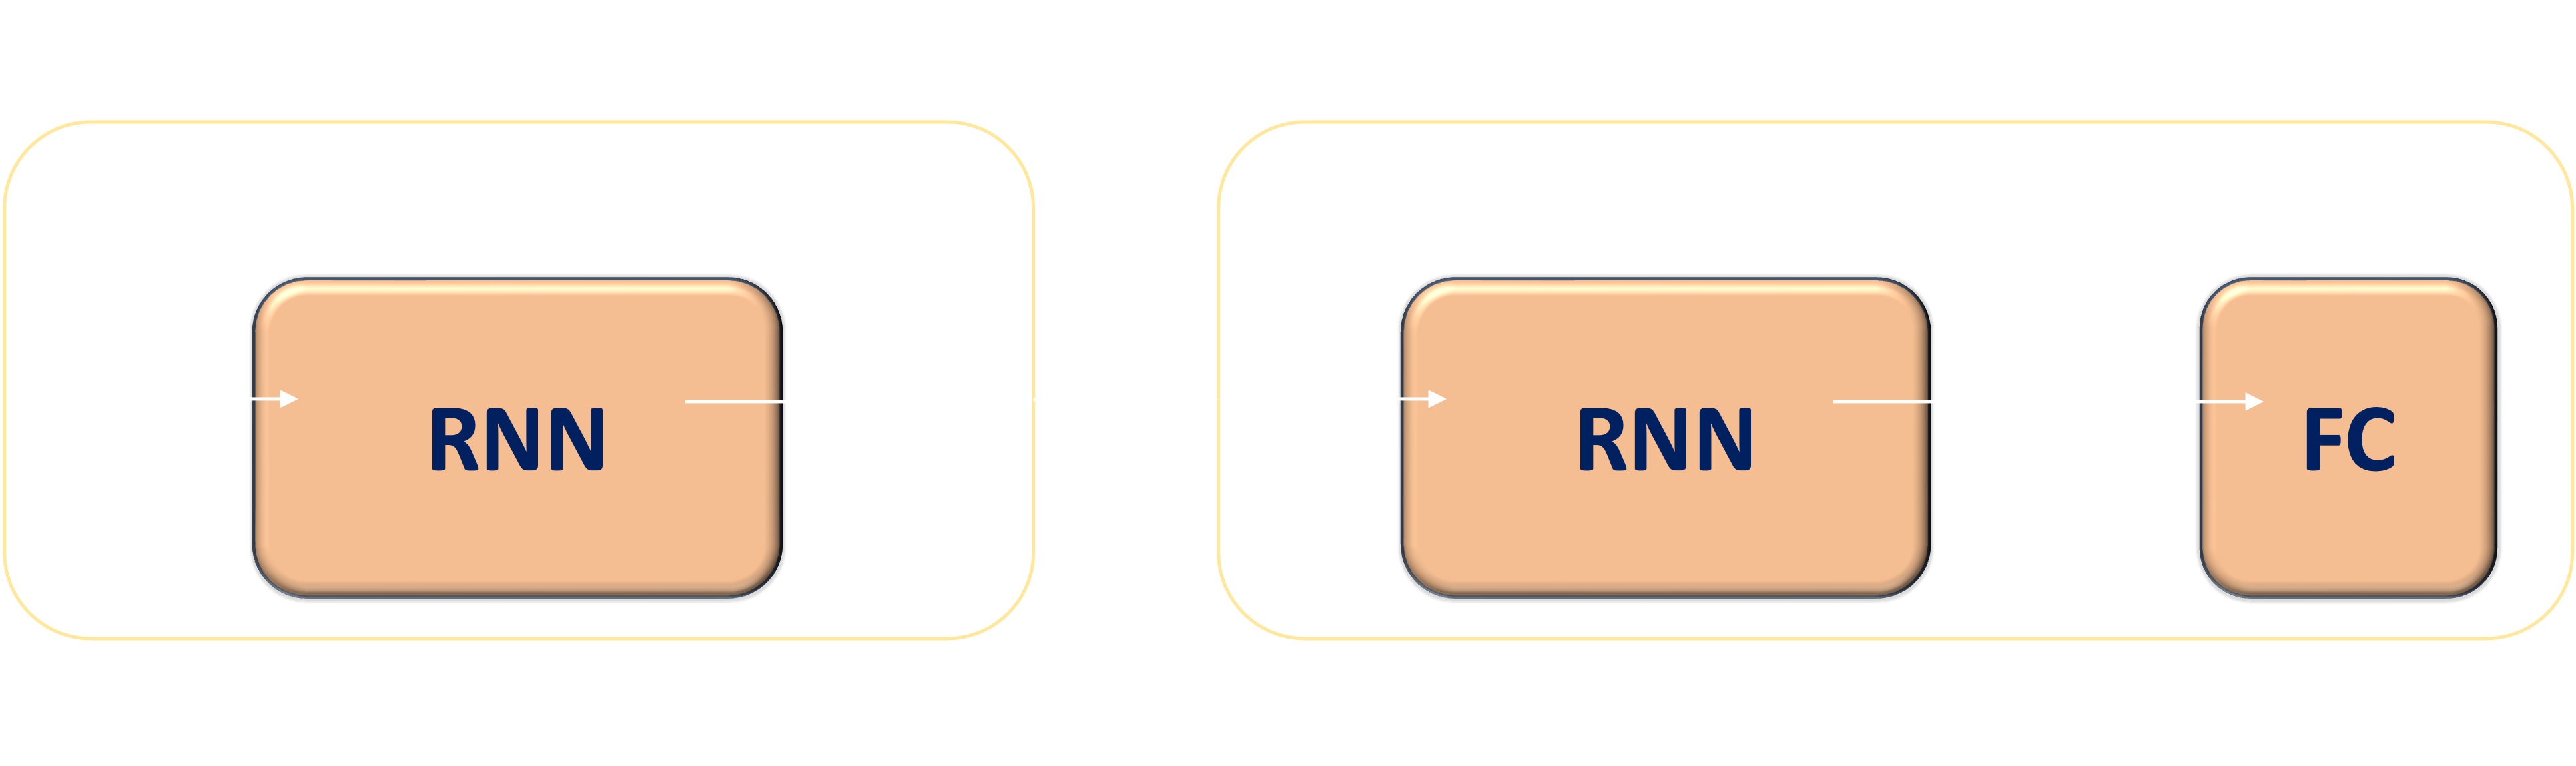

In [8]:
import torch
import torch.nn as nn

class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(EncoderRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        # We only care about the final hidden state (the Context Vector)
        _, hidden = self.rnn(embedded)
        return hidden # Shape: (num_layers, batch_size, hidden_dim)

class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x is usually the very last word of the input sequence
        # to start the "prediction" phase
        embedded = self.embedding(x).unsqueeze(1) # Add seq_len dim
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

class Seq2SeqNextWord(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqNextWord, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        # 1. Encode the input sequence into a context vector
        context_vector = self.encoder(x)

        # 2. For next-word prediction, the decoder needs a "starting word".
        # We typically use the last word of the input sequence (x[:, -1])
        start_token = x[:, -1]

        # 3. Decode the next word using the context vector
        prediction, _ = self.decoder(start_token, context_vector)

        return prediction

# --- Setup and Verification ---

vocabulary_size = 10000
embedding_dim = 64
hidden_size = 256

encoder = EncoderRNN(vocabulary_size, embedding_dim, hidden_size)
decoder = DecoderRNN(vocabulary_size, embedding_dim, hidden_size)
rnn_model = Seq2SeqNextWord(encoder, decoder).to(device)

print("Encoder-Decoder Model defined.")

# Verification with dummy data or your train_loader
example_batch_data = torch.randint(0, vocabulary_size, (32, 15)).to(device) # (batch, seq_len)

with torch.no_grad():
    sample_output = rnn_model(example_batch_data)

print(f"Input shape: {example_batch_data.shape}")
print(f"Output shape (Next Word Logits): {sample_output.shape}")

Encoder-Decoder Model defined.
Input shape: torch.Size([32, 15])
Output shape (Next Word Logits): torch.Size([32, 10000])


### **Training Loop Overview and Top-K Accuracy**

The training loop is designed to iteratively teach the RNN model to predict the next word in a sequence. For each epoch:

1.  **Forward Pass:** Input sequences (14 words) are fed through the model to generate predictions for the 15th word.
2.  **Loss Calculation:** The `CrossEntropyLoss` compares the model's predicted word distribution with the actual 15th word, quantifying the error.
3.  **Backward Pass & Optimization:** The calculated loss is used to compute gradients, and the `Adam` optimizer updates the model's weights to reduce this error.

**Top-K Accuracy:** In next-word prediction, predicting the *exact* word can be very challenging, and often several words could be contextually correct. Therefore, instead of strict 'top-1' accuracy (where only the single highest-probability prediction counts), we're using **Top-5 Accuracy**.

This means a prediction is considered **accurate** if the true next word is among the **top 5 words** that the model predicted with the highest probabilities. This metric provides a more forgiving and often more realistic measure of a language model's predictive performance.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(model, train_loader, optimizer, criterion, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"Training on {device}")

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(data)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy (Top-5)
            _, top5_predicted = torch.topk(outputs, k=5, dim=1) # Get top 5 predictions
            # Check if the true label is among the top 5 predictions for each sample
            correct_train += (top5_predicted == labels.unsqueeze(1)).any(dim=1).sum().item()
            total_train += labels.size(0)

        avg_train_loss_epoch = running_loss / (len(train_loader) % 100 or 100) if running_loss > 0 else 0.0
        if running_loss == 0.0: # If running_loss was reset to 0 in the last print
             # Recalculate average loss for the last partial 100 steps or for entire epoch if no prints
            total_epoch_loss = 0.0
            total_epoch_samples = 0
            for data, labels in train_loader:
                 data, labels = data.to(device), labels.to(device)
                 outputs = model(data)
                 loss = criterion(outputs, labels)
                 total_epoch_loss += loss.item() * labels.size(0)
                 total_epoch_samples += labels.size(0)
            avg_train_loss_epoch = total_epoch_loss / total_epoch_samples if total_epoch_samples > 0 else 0.0

        train_accuracy = 100 * correct_train / total_train


        print(f"Epoch [{epoch+1}/{num_epochs}] completed.")
        print(f"Train Loss: {avg_train_loss_epoch:.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print("--------------------------------------------------")

    print("Finished Training!")

In [10]:
# Instantiate the model (if not already done or if a fresh model is desired)
# model = NextWordRNN(vocabulary_size, embedding_dim, hidden_size)

# Define Optimizer and Loss Function
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.")

# Set number of training epochs
num_epochs = 10

# Call the training function
train_model(rnn_model, train_loader_15_words, optimizer, criterion, num_epochs)

Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.


In [11]:
# Set number of training epochs
num_epochs = 10

# Call the training function
train_model(rnn_model, train_loader_15_words, optimizer, criterion, num_epochs)

Training on cuda
Epoch [1/10] completed.
Train Loss: 786.2562, Train Accuracy: 23.96%
--------------------------------------------------
Epoch [2/10] completed.
Train Loss: 727.8314, Train Accuracy: 27.32%
--------------------------------------------------
Epoch [3/10] completed.
Train Loss: 702.7708, Train Accuracy: 28.68%
--------------------------------------------------
Epoch [4/10] completed.
Train Loss: 684.2712, Train Accuracy: 29.67%
--------------------------------------------------
Epoch [5/10] completed.
Train Loss: 669.1529, Train Accuracy: 30.49%
--------------------------------------------------
Epoch [6/10] completed.
Train Loss: 657.2680, Train Accuracy: 31.12%
--------------------------------------------------
Epoch [7/10] completed.
Train Loss: 646.1387, Train Accuracy: 31.85%
--------------------------------------------------
Epoch [8/10] completed.
Train Loss: 636.1036, Train Accuracy: 32.46%
--------------------------------------------------
Epoch [9/10] completed.

### **Generating Word Sequences with the RNN Model**

In this section, we demonstrated the generative capability of the trained RNN model for next-word prediction. Instead of providing a full 9-word input sequence, we initiated the process with just a single starting word and allowed the model to iteratively predict the subsequent words.

Here's how the sequence generation works:

1.  **Starting Word:** We provide an initial word (e.g., "I", "they").
2.  **First Prediction:** The model takes this single word as input and predicts the most probable next word.
3.  **Iterative Expansion:** The newly predicted word is then appended to the initial word, creating a two-word sequence. This new sequence is fed back into the model to predict the *next* word.
4.  **Repeat:** This process is repeated 9 times, building a complete 10-word sequence (initial word + 9 predicted words).

This iterative prediction showcases how recurrent neural networks can be used for tasks like text generation, where the output of one step becomes the input for the next, allowing the model to build coherent sequences over time. The quality of the generated sequences reflects the patterns and structures learned by the model during its training on the IMDB dataset.

In [12]:
import torch

# Ensure the model is in evaluation mode
rnn_model.eval()

# Define the starting words
starting_words = ["I", "They", "Happy", "Movie", "Million"]

# Get word_index and reverse_word_index (assuming they are already in memory)
# If not, uncomment and run the following lines:
# from tensorflow.keras.datasets import imdb
# word_index = imdb.get_word_index()
# reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def encode_word(word, word_index):
    # Add 3 to the word index as imdb.load_data shifts indices
    # Use 1 (start of sequence token) as default for unknown words
    return word_index.get(word, 1) + 3

def decode_sequence_full(sequence_tensor):
    decoded_words = []
    for word_idx in sequence_tensor.tolist():
        if word_idx == 0: # Padding token
            decoded_words.append('')
        elif word_idx < 4: # Special tokens (1: start, 2: unknown, 3: unused)
            decoded_words.append('?')
        else:
            decoded_words.append(reverse_word_index.get(word_idx - 3, '?'))
    return ' '.join(decoded_words).strip()

print("--- Generating next 9 words from a starting word ---")

generated_sequences = []
num_words_to_generate = 14 # We want to predict 9 words after the starting word

for start_word_str in starting_words:
    # Encode the starting word
    initial_word_idx = encode_word(start_word_str.lower(), word_index) # Convert to lowercase for consistent lookup
    current_sequence = [initial_word_idx]

    for _ in range(num_words_to_generate):
        # Convert current sequence to tensor, add batch dimension
        input_tensor = torch.tensor(current_sequence, dtype=torch.long).unsqueeze(0)

        # Move to the correct device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            output = rnn_model(input_tensor)

        # Get the predicted word index (the one with the highest probability)
        _, predicted_idx = torch.max(output, 1)

        # Append the predicted word's index to the current sequence
        current_sequence.append(predicted_idx.item())

    # Decode the entire generated sequence
    full_sequence_tensor = torch.tensor(current_sequence, dtype=torch.long)
    decoded_generated_sequence = decode_sequence_full(full_sequence_tensor)
    generated_sequences.append((start_word_str, decoded_generated_sequence))

for i, (start_word, generated_text) in enumerate(generated_sequences):
    print(f"Sequence {i+1} (started with '{start_word}'):")
    print(f"  '{generated_text}'")
    print("--------------------------------------------------")

--- Generating next 9 words from a starting word ---
Sequence 1 (started with 'I'):
  'i was convinced that the sheriff and the blob comes to the audience is a'
--------------------------------------------------
Sequence 2 (started with 'They'):
  'they can see the film is a good movie that is the way to the'
--------------------------------------------------
Sequence 3 (started with 'Happy'):
  'happy ending and the greatest genre and the way to the front of the film'
--------------------------------------------------
Sequence 4 (started with 'Movie'):
  'movie that the movie is not a very good and the movie is a good'
--------------------------------------------------
Sequence 5 (started with 'Million'):
  'million and the muppets and the result is the way to the audience is a'
--------------------------------------------------


### **Analyzing Word Embedding Visualization**

This UMAP plot provides a 2D projection of the word embeddings learned by your RNN. In an ideal scenario, words that are semantically similar (e.g., 'good', 'great', 'excellent' or 'bad', 'terrible', 'awful') should cluster together in this reduced-dimensional space.

*   **Clusters:** Look for groupings of words. Do words with similar meanings appear close to each other? For example, are positive sentiment words distinct from negative ones?
*   **Isolated Words:** Are there any words that are far away from all others? These might be unique or rare words, or words that the model hasn't found strong contextual relationships for during training.
*   **Unexpected Neighbors:** Sometimes, words might appear close together unexpectedly. This could indicate the model learned a relationship based on co-occurrence in the dataset rather than pure semantic similarity (e.g., 'movie' and 'film' will likely be close, but 'movie' and 'popcorn' might also be, if 'popcorn' frequently appears near 'movie' in reviews).

This visualization helps to informally assess the quality of the learned embeddings and understand how the model perceives the relationships between words based on the training data.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_25287/207136564.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors


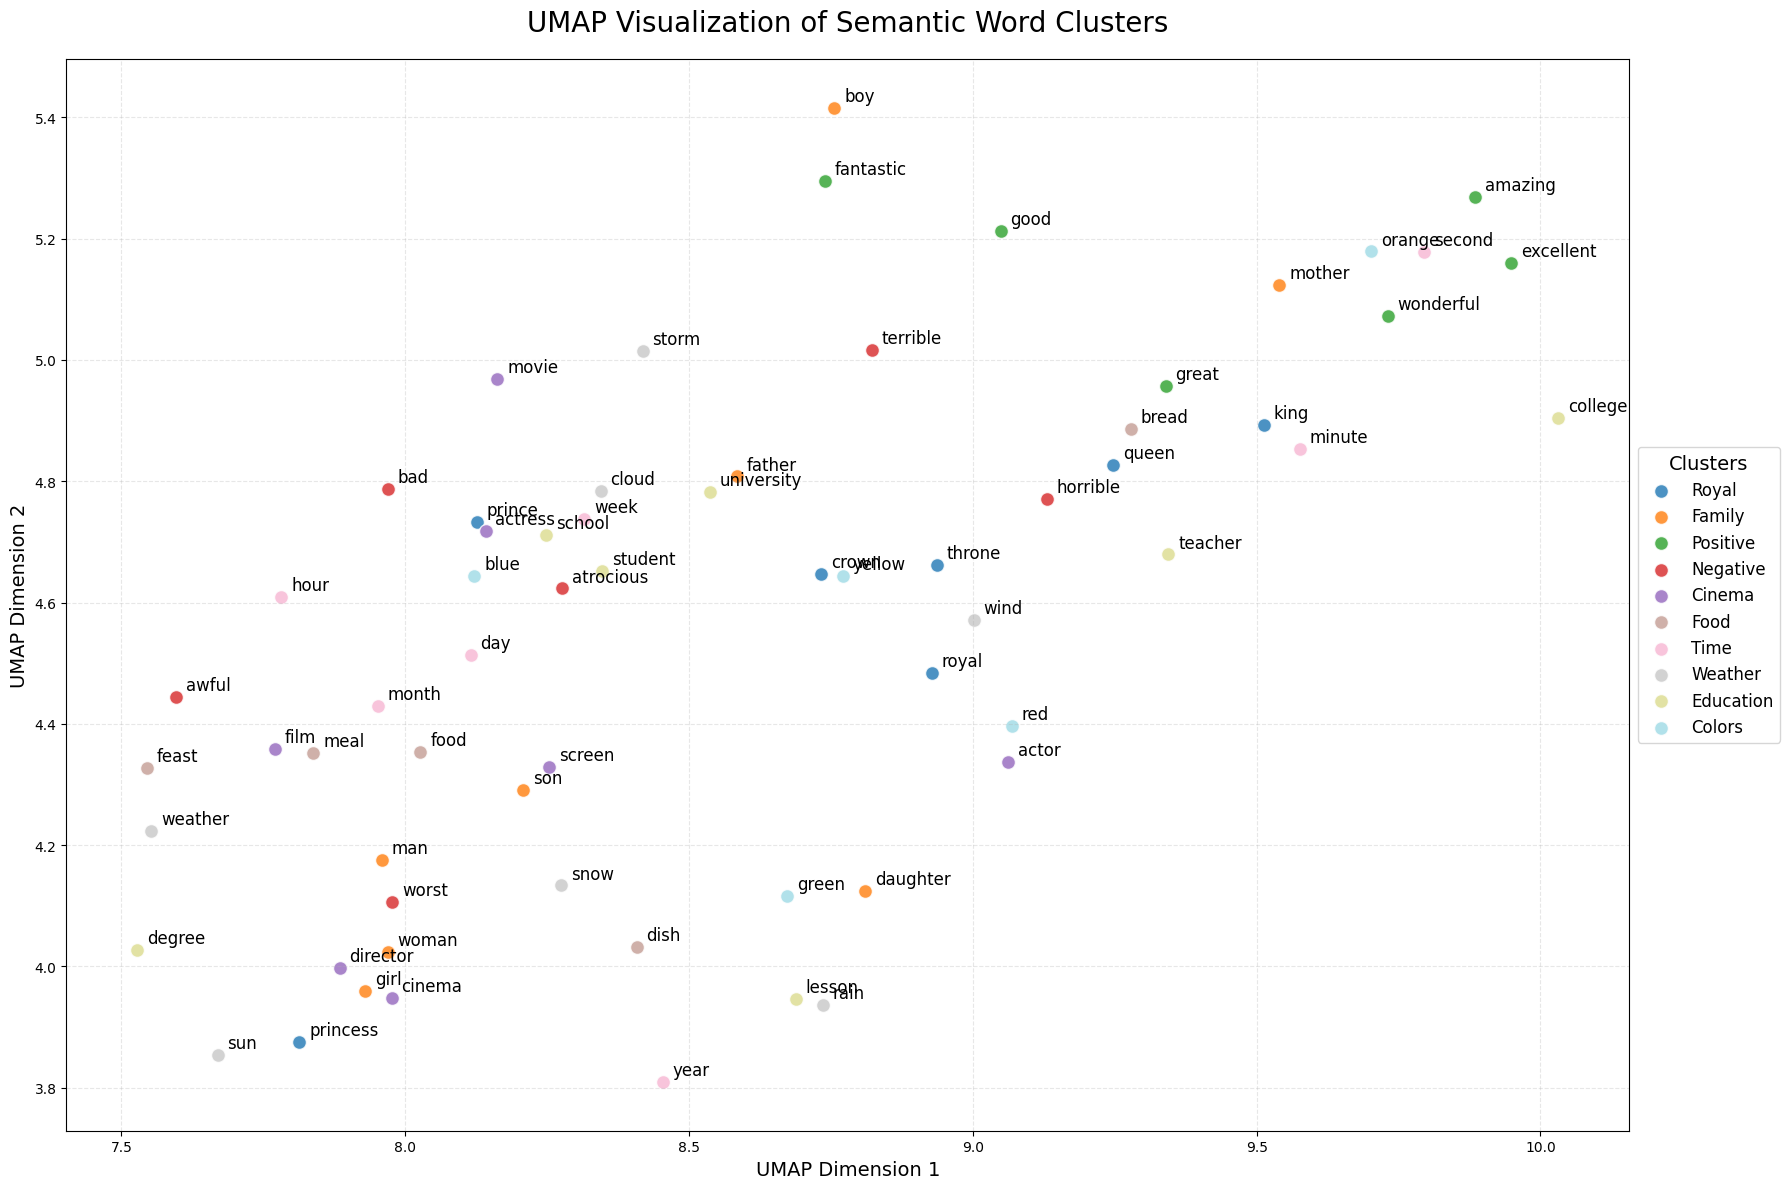

In [13]:
import matplotlib.pyplot as plt
import umap
import numpy as np
import torch

# 1. Setup Data Clusters
# Organized as a dictionary to easily assign colors/labels
clusters = {
    "Royal": ["king", "queen", "prince", "princess", "royal", "throne", "crown"],
    "Family": ["man", "woman", "boy", "girl", "father", "mother", "son", "daughter"],
    "Positive": ["good", "great", "excellent", "amazing", "wonderful", "fantastic"],
    "Negative": ["bad", "terrible", "awful", "horrible", "atrocious", "worst"],
    "Cinema": ["film", "movie", "cinema", "screen", "director", "actor", "actress"],
    "Food": ["bread", "meal", "food", "dish", "cuisine", "snack", "feast"],
    "Time": ["second", "minute", "hour", "day", "week", "month", "year"],
    "Weather": ["sun", "rain", "cloud", "storm", "wind", "snow", "weather"],
    "Education": ["school", "college", "university", "student", "teacher", "lesson", "degree"],
    "Colors": ["blue","red","orange","yellow","green"]
}

# 2. Extract Embeddings
selected_indices = []
selected_words = []
word_to_category = {}

for category, words in clusters.items():
    for word in words:
        original_idx = word_index.get(word, None)
        if original_idx is not None:
            shifted_idx = original_idx + 3
            if 4 <= shifted_idx < vocabulary_size:
                selected_indices.append(shifted_idx)
                selected_words.append(word)
                word_to_category[word] = category

if not selected_indices:
    print("No specified cluster words found in vocabulary.")
else:
    # Move model to CPU and get weights
    rnn_model.eval()
    word_embeddings = rnn_model.encoder.embedding.weight.data.cpu().numpy()
    selected_embeddings = np.array([word_embeddings[idx] for idx in selected_indices])

    # 3. Apply UMAP
    reducer = umap.UMAP(n_neighbors=7, min_dist=0.01, n_components=5, random_state=42)
    reduced_embeddings = reducer.fit_transform(selected_embeddings)

    # 4. Plotting
    plt.figure(figsize=(18, 12))

    # Use a colormap to get distinct colors for each category
    categories = list(clusters.keys())
    colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors
    category_to_color = {cat: colors(i) for i, cat in enumerate(categories)}

    # Track which categories we've added to the legend
    seen_categories = set()

    for i, word in enumerate(selected_words):
        x, y = reduced_embeddings[i, 0], reduced_embeddings[i, 1]
        category = word_to_category[word]

        # Plot point
        label = category if category not in seen_categories else None
        plt.scatter(x, y, color=category_to_color[category], s=100, label=label, edgecolors='white', alpha=0.8)
        seen_categories.add(category)

        # Annotate with larger font
        plt.annotate(
            word,
            (x, y),
            textcoords="offset points",
            xytext=(7, 5),
            ha='left',
            fontsize=12,  # Increased font size
            fontweight='medium'
        )

    plt.title('UMAP Visualization of Semantic Word Clusters', fontsize=20, pad=20)
    plt.xlabel('UMAP Dimension 1', fontsize=14)
    plt.ylabel('UMAP Dimension 2', fontsize=14)

    # Place legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, title="Clusters", title_fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Gated Recurrent Units (GRUs)**

Gated Recurrent Units (GRUs) are a type of recurrent neural network that, like LSTMs, were designed to solve the vanishing gradient problem that plagues standard RNNs. GRUs are a simplified version of LSTMs, offering a good balance between performance and computational efficiency.

Key characteristics:

*   **Simplified Gates:** GRUs have two gates: an update gate and a reset gate. These gates control how information flows through the network and how much of the past memory is kept or forgotten.
*   **No Cell State:** Unlike LSTMs, GRUs do not have a separate cell state. Instead, they directly expose the hidden state to control the information flow.
*   **Addresses Vanishing Gradient:** The gating mechanisms allow GRUs to effectively capture dependencies across longer sequences, making them suitable for tasks where long-term context is important.
*   **Efficiency:** Being simpler than LSTMs, GRUs generally have fewer parameters, leading to faster training times and requiring less data to generalize.

GRUs are widely used in sequence modeling tasks, particularly in natural language processing, due to their ability to learn long-range dependencies while being relatively computationally inexpensive.

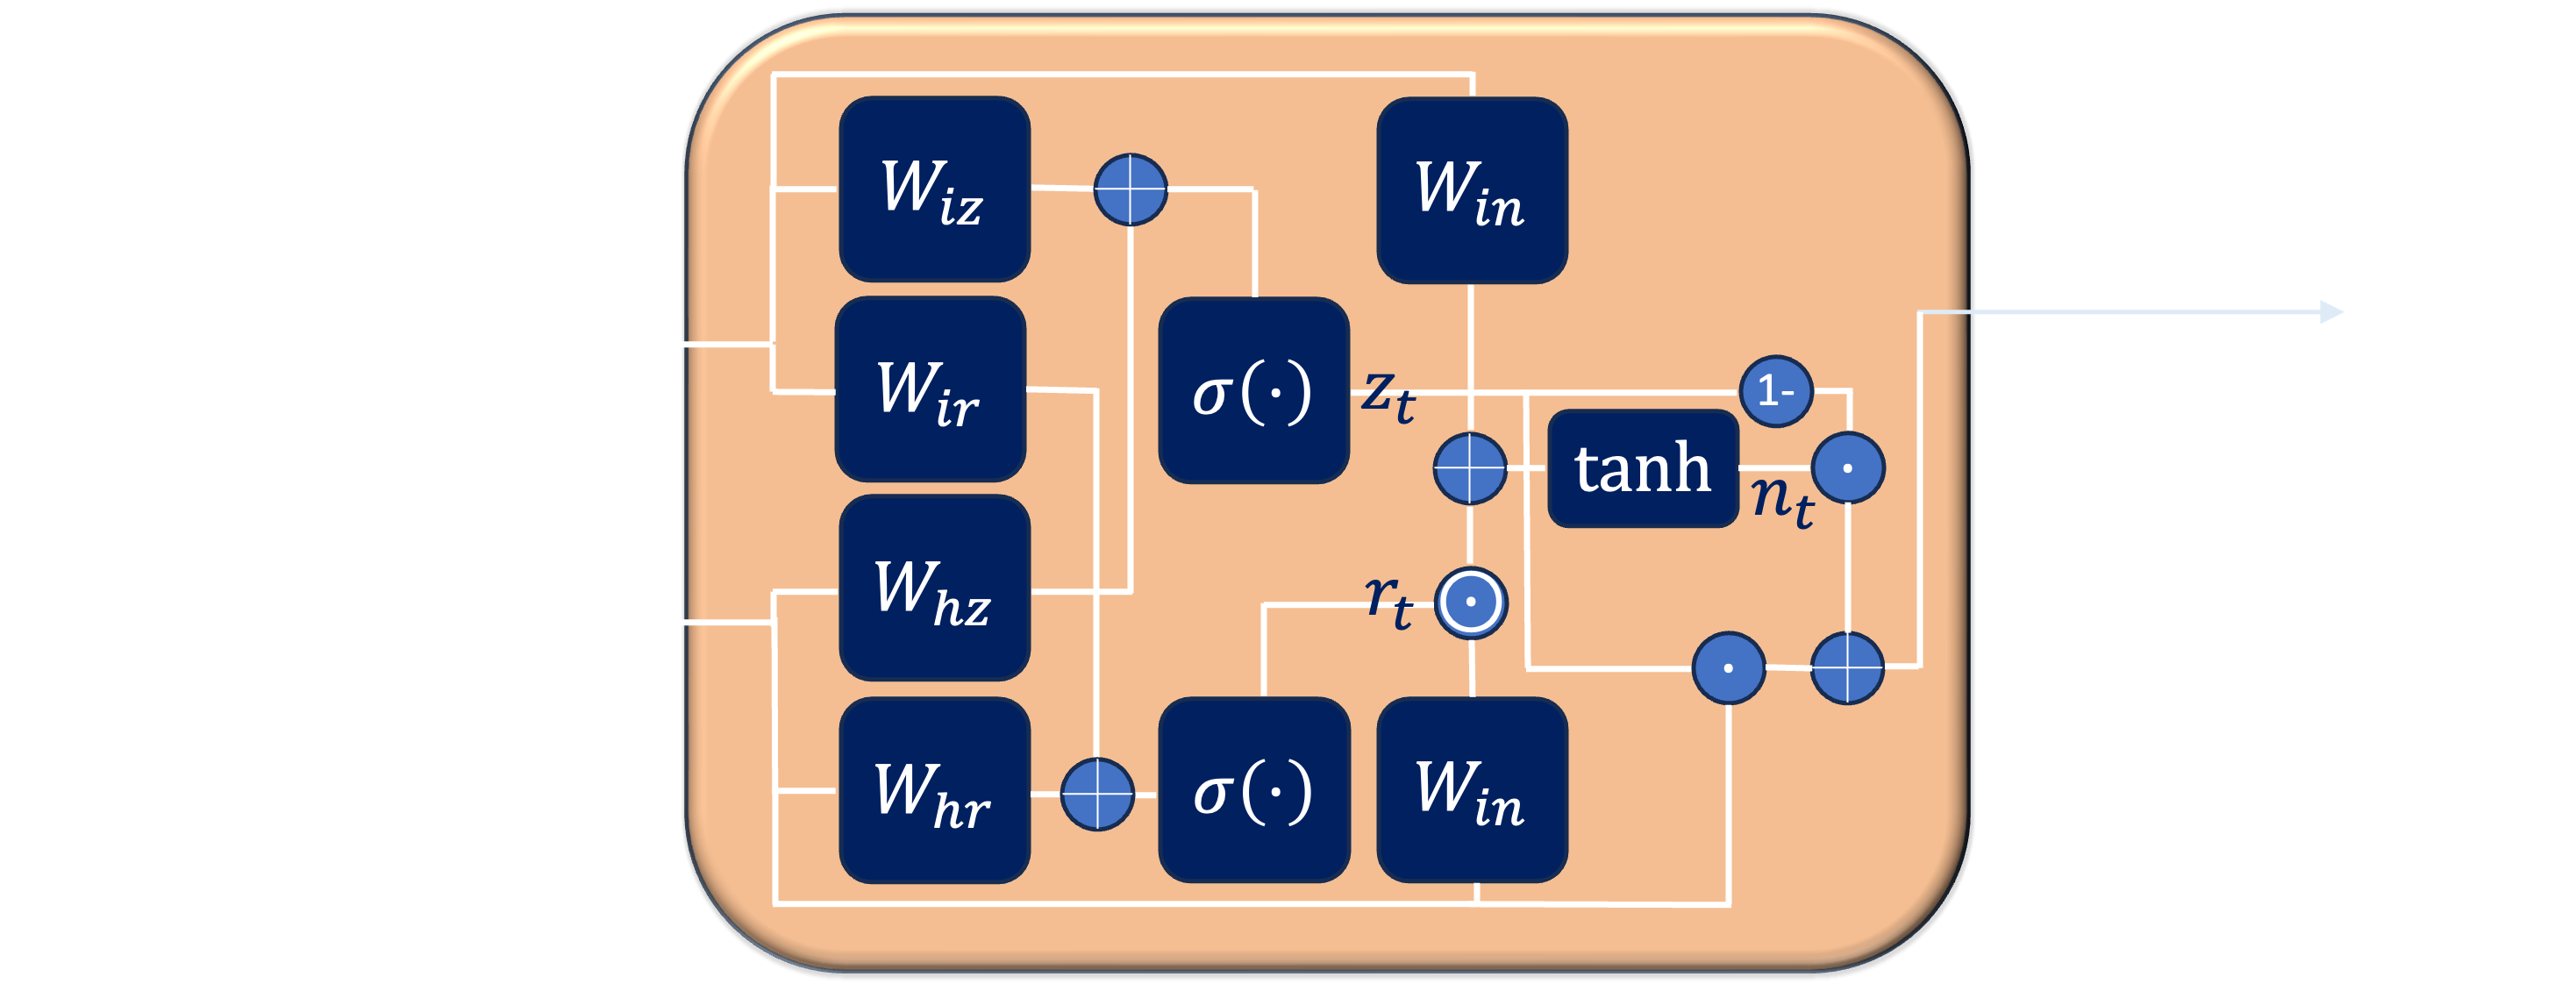

In [18]:
import torch
import torch.nn as nn

class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(EncoderGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        # We only care about the final hidden state (the Context Vector)
        _, hidden = self.gru(embedded)
        return hidden # Shape: (num_layers, batch_size, hidden_dim)

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(DecoderGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x is usually the very last word of the input sequence
        # to start the "prediction" phase
        embedded = self.embedding(x).unsqueeze(1) # Add seq_len dim
        output, hidden = self.gru(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

class Seq2SeqNextWord(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqNextWord, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        # 1. Encode the input sequence into a context vector
        context_vector = self.encoder(x)

        # 2. For next-word prediction, the decoder needs a "starting word".
        # We typically use the last word of the input sequence (x[:, -1])
        start_token = x[:, -1]

        # 3. Decode the next word using the context vector
        prediction, _ = self.decoder(start_token, context_vector)

        return prediction

# --- Setup and Verification ---

vocabulary_size = 10000
embedding_dim = 64
hidden_size = 256

encoder = EncoderGRU(vocabulary_size, embedding_dim, hidden_size)
decoder = DecoderGRU(vocabulary_size, embedding_dim, hidden_size)
gru_model = Seq2SeqNextWord(encoder, decoder).to(device)

print("Encoder-Decoder Model defined.")

# Verification with dummy data or your train_loader
example_batch_data = torch.randint(0, vocabulary_size, (32, 15)).to(device) # (batch, seq_len)

with torch.no_grad():
    sample_output = gru_model(example_batch_data)

print(f"Input shape: {example_batch_data.shape}")
print(f"Output shape (Next Word Logits): {sample_output.shape}")

Encoder-Decoder Model defined.
Input shape: torch.Size([32, 15])
Output shape (Next Word Logits): torch.Size([32, 10000])


In [19]:
# Define Optimizer and Loss Function
optimizer = optim.Adam(gru_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

print("Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.")

# Set number of training epochs
num_epochs = 10 # You can adjust this value

# Call the training function
train_model(gru_model, train_loader_15_words, optimizer, criterion, num_epochs)

Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.
Training on cuda
Epoch [1/10] completed.
Train Loss: 744.0411, Train Accuracy: 27.59%
--------------------------------------------------
Epoch [2/10] completed.
Train Loss: 651.4504, Train Accuracy: 33.62%
--------------------------------------------------
Epoch [3/10] completed.
Train Loss: 590.0185, Train Accuracy: 37.62%
--------------------------------------------------
Epoch [4/10] completed.
Train Loss: 535.5672, Train Accuracy: 42.13%
--------------------------------------------------
Epoch [5/10] completed.
Train Loss: 487.5648, Train Accuracy: 47.52%
--------------------------------------------------
Epoch [6/10] completed.
Train Loss: 447.5635, Train Accuracy: 52.49%
--------------------------------------------------
Epoch [7/10] completed.
Train Loss: 414.5922, Train Accuracy: 57.00%
--------------------------------------------------
Epoch [8/10] completed.
Train Loss: 387.7814, Train Accuracy: 60.59%
-----------

### **Train GRU**

In [20]:
# Ensure the model is in evaluation mode
gru_model.eval()

# Define the starting words
starting_words = ["I", "They", "Happy", "Movie", "Million"]

print("--- Generating next 9 words from a starting word ---")

generated_sequences = []
num_words_to_generate = 14 # We want to predict 9 words after the starting word

for start_word_str in starting_words:
    # Encode the starting word
    initial_word_idx = encode_word(start_word_str.lower(), word_index) # Convert to lowercase for consistent lookup
    current_sequence = [initial_word_idx]

    for _ in range(num_words_to_generate):
        # Convert current sequence to tensor, add batch dimension
        input_tensor = torch.tensor(current_sequence, dtype=torch.long).unsqueeze(0)

        # Move to the correct device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            output = gru_model(input_tensor)

        # Get the predicted word index (the one with the highest probability)
        _, predicted_idx = torch.max(output, 1)

        # Append the predicted word's index to the current sequence
        current_sequence.append(predicted_idx.item())

    # Decode the entire generated sequence
    full_sequence_tensor = torch.tensor(current_sequence, dtype=torch.long)
    decoded_generated_sequence = decode_sequence_full(full_sequence_tensor)
    generated_sequences.append((start_word_str, decoded_generated_sequence))

for i, (start_word, generated_text) in enumerate(generated_sequences):
    print(f"Sequence {i+1} (started with '{start_word}'):")
    print(f"  '{generated_text}'")
    print("--------------------------------------------------")

--- Generating next 9 words from a starting word ---
Sequence 1 (started with 'I'):
  'i have never seen anything but it was like i said it was so disappointed'
--------------------------------------------------
Sequence 2 (started with 'They'):
  'they are the most future and decide to make a movie about this one out'
--------------------------------------------------
Sequence 3 (started with 'Happy'):
  'happy birthday to me now i have ever seen and i am sorry for the'
--------------------------------------------------
Sequence 4 (started with 'Movie'):
  'movie i think that the movie was awful and i was able to support the'
--------------------------------------------------
Sequence 5 (started with 'Million'):
  'million dollar business and jennifer spencer high profile as satan himself and who can blame'
--------------------------------------------------


### **Word Embedding Visualization**

UMAP plot of the word embeddings learned by your GRU.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_25287/563437142.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors


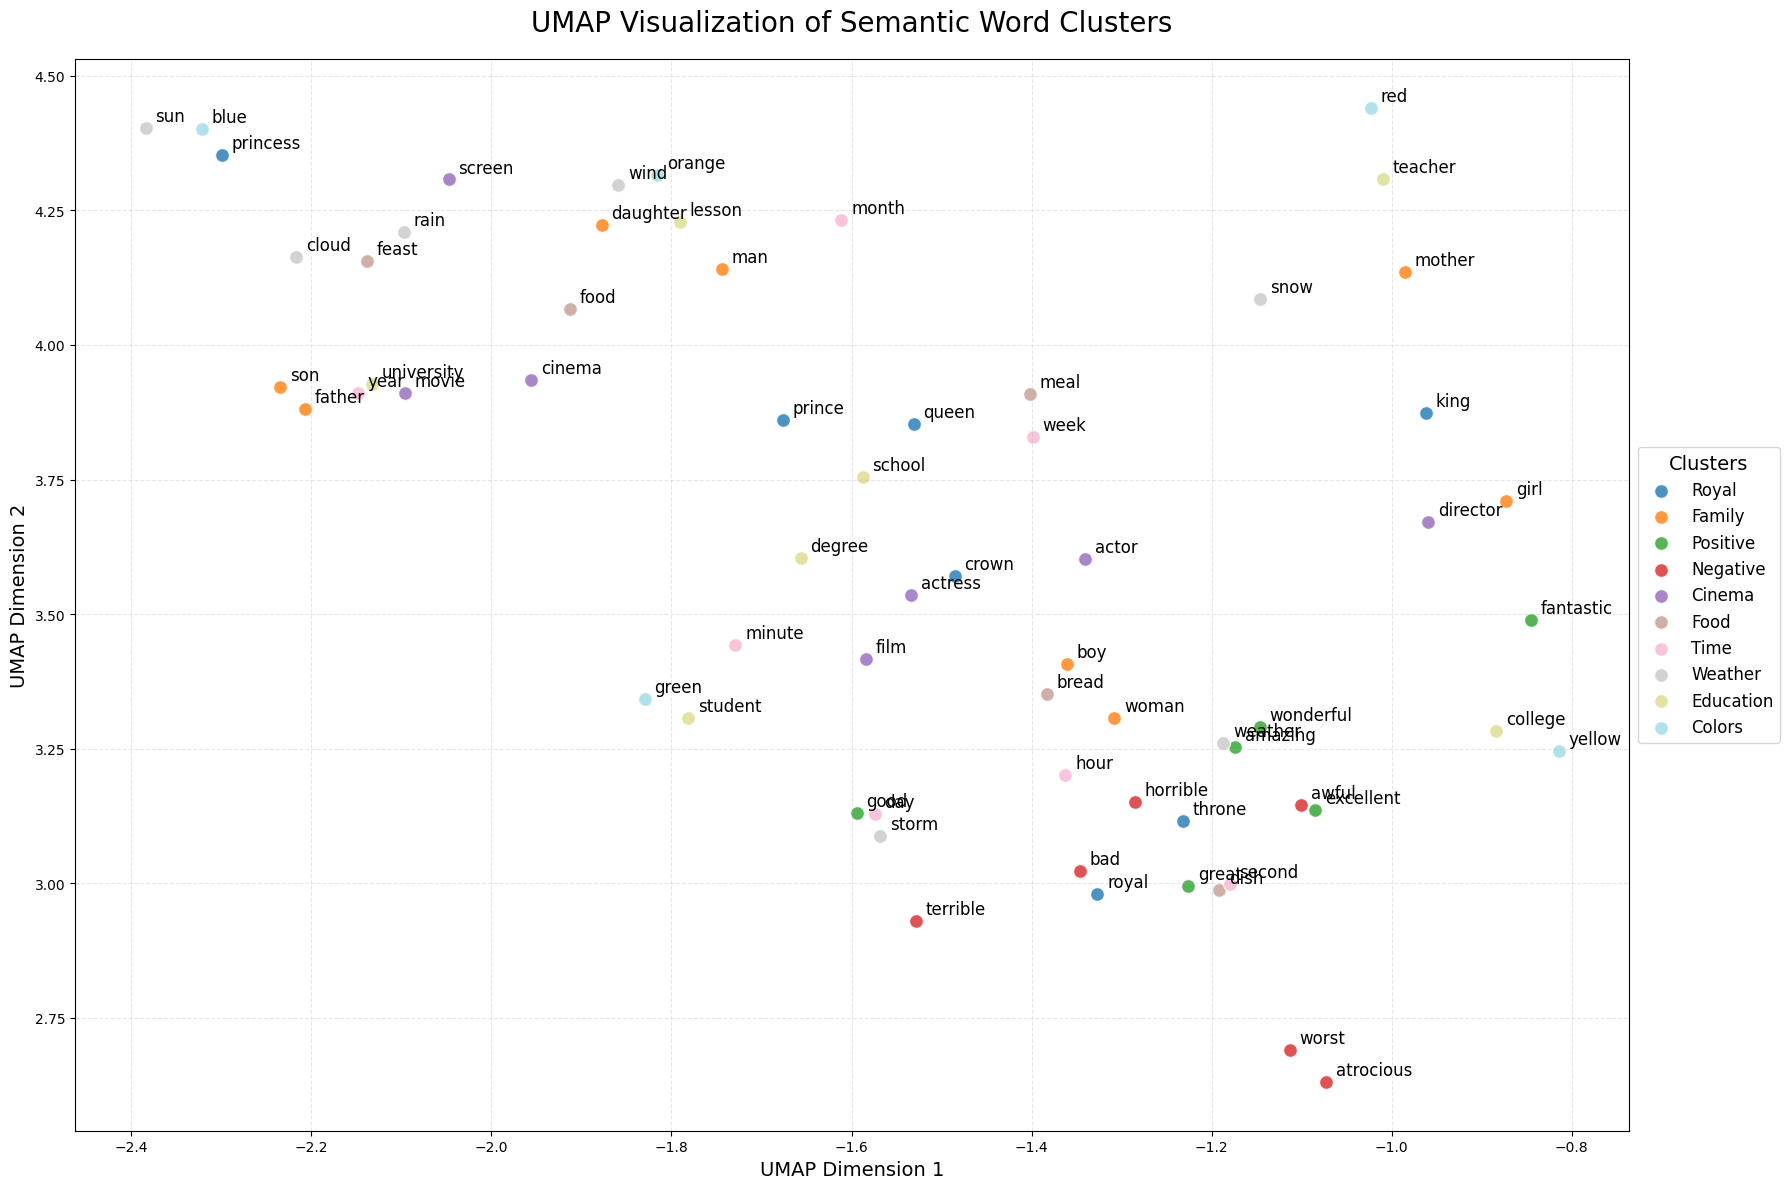

In [21]:
import matplotlib.pyplot as plt
import umap
import numpy as np
import torch

# 1. Setup Data Clusters
# Organized as a dictionary to easily assign colors/labels
clusters = {
    "Royal": ["king", "queen", "prince", "princess", "royal", "throne", "crown"],
    "Family": ["man", "woman", "boy", "girl", "father", "mother", "son", "daughter"],
    "Positive": ["good", "great", "excellent", "amazing", "wonderful", "fantastic"],
    "Negative": ["bad", "terrible", "awful", "horrible", "atrocious", "worst"],
    "Cinema": ["film", "movie", "cinema", "screen", "director", "actor", "actress"],
    "Food": ["bread", "meal", "food", "dish", "cuisine", "snack", "feast"],
    "Time": ["second", "minute", "hour", "day", "week", "month", "year"],
    "Weather": ["sun", "rain", "cloud", "storm", "wind", "snow", "weather"],
    "Education": ["school", "college", "university", "student", "teacher", "lesson", "degree"],
    "Colors": ["blue","red","orange","yellow","green"]
}

# 2. Extract Embeddings
selected_indices = []
selected_words = []
word_to_category = {}

for category, words in clusters.items():
    for word in words:
        original_idx = word_index.get(word, None)
        if original_idx is not None:
            shifted_idx = original_idx + 3
            if 4 <= shifted_idx < vocabulary_size:
                selected_indices.append(shifted_idx)
                selected_words.append(word)
                word_to_category[word] = category

if not selected_indices:
    print("No specified cluster words found in vocabulary.")
else:
    # Move model to CPU and get weights
    gru_model.eval()
    word_embeddings = gru_model.encoder.embedding.weight.data.cpu().numpy()
    selected_embeddings = np.array([word_embeddings[idx] for idx in selected_indices])

    # 3. Apply UMAP
    reducer = umap.UMAP(n_neighbors=7, min_dist=0.01, n_components=8, random_state=42)
    reduced_embeddings = reducer.fit_transform(selected_embeddings)

    # 4. Plotting
    plt.figure(figsize=(18, 12))

    # Use a colormap to get distinct colors for each category
    categories = list(clusters.keys())
    colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors
    category_to_color = {cat: colors(i) for i, cat in enumerate(categories)}

    # Track which categories we've added to the legend
    seen_categories = set()

    for i, word in enumerate(selected_words):
        x, y = reduced_embeddings[i, 0], reduced_embeddings[i, 1]
        category = word_to_category[word]

        # Plot point
        label = category if category not in seen_categories else None
        plt.scatter(x, y, color=category_to_color[category], s=100, label=label, edgecolors='white', alpha=0.8)
        seen_categories.add(category)

        # Annotate with larger font
        plt.annotate(
            word,
            (x, y),
            textcoords="offset points",
            xytext=(7, 5),
            ha='left',
            fontsize=12,  # Increased font size
            fontweight='medium'
        )

    plt.title('UMAP Visualization of Semantic Word Clusters', fontsize=20, pad=20)
    plt.xlabel('UMAP Dimension 1', fontsize=14)
    plt.ylabel('UMAP Dimension 2', fontsize=14)

    # Place legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, title="Clusters", title_fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Long Short-Term Memory (LSTMs)**

Long Short-Term Memory (LSTMs) are a special kind of recurrent neural network, introduced to deal with the vanishing gradient problem encountered by standard RNNs. LSTMs are capable of learning long-term dependencies.

Key characteristics:

*   **Gate Mechanisms:** LSTMs utilize a more complex gating mechanism than GRUs, typically consisting of three gates: an input gate, a forget gate, and an output gate. These gates regulate the flow of information into and out of the cell state.
*   **Cell State:** Unlike GRUs, LSTMs maintain a separate 'cell state' (or memory cell) that can carry information across long sequences, making them very effective at remembering important data over extended periods.
*   **Addresses Vanishing/Exploding Gradients:** The gates allow LSTMs to selectively add or remove information from the cell state, preventing older information from vanishing too quickly or gradients from exploding during training.
*   **Performance:** LSTMs are widely used and often achieve state-of-the-art results in various sequence modeling tasks, especially when long-term dependencies are critical.

LSTMs are foundational in many advanced natural language processing applications, including machine translation, speech recognition, and complex text generation, due to their robust memory capabilities.

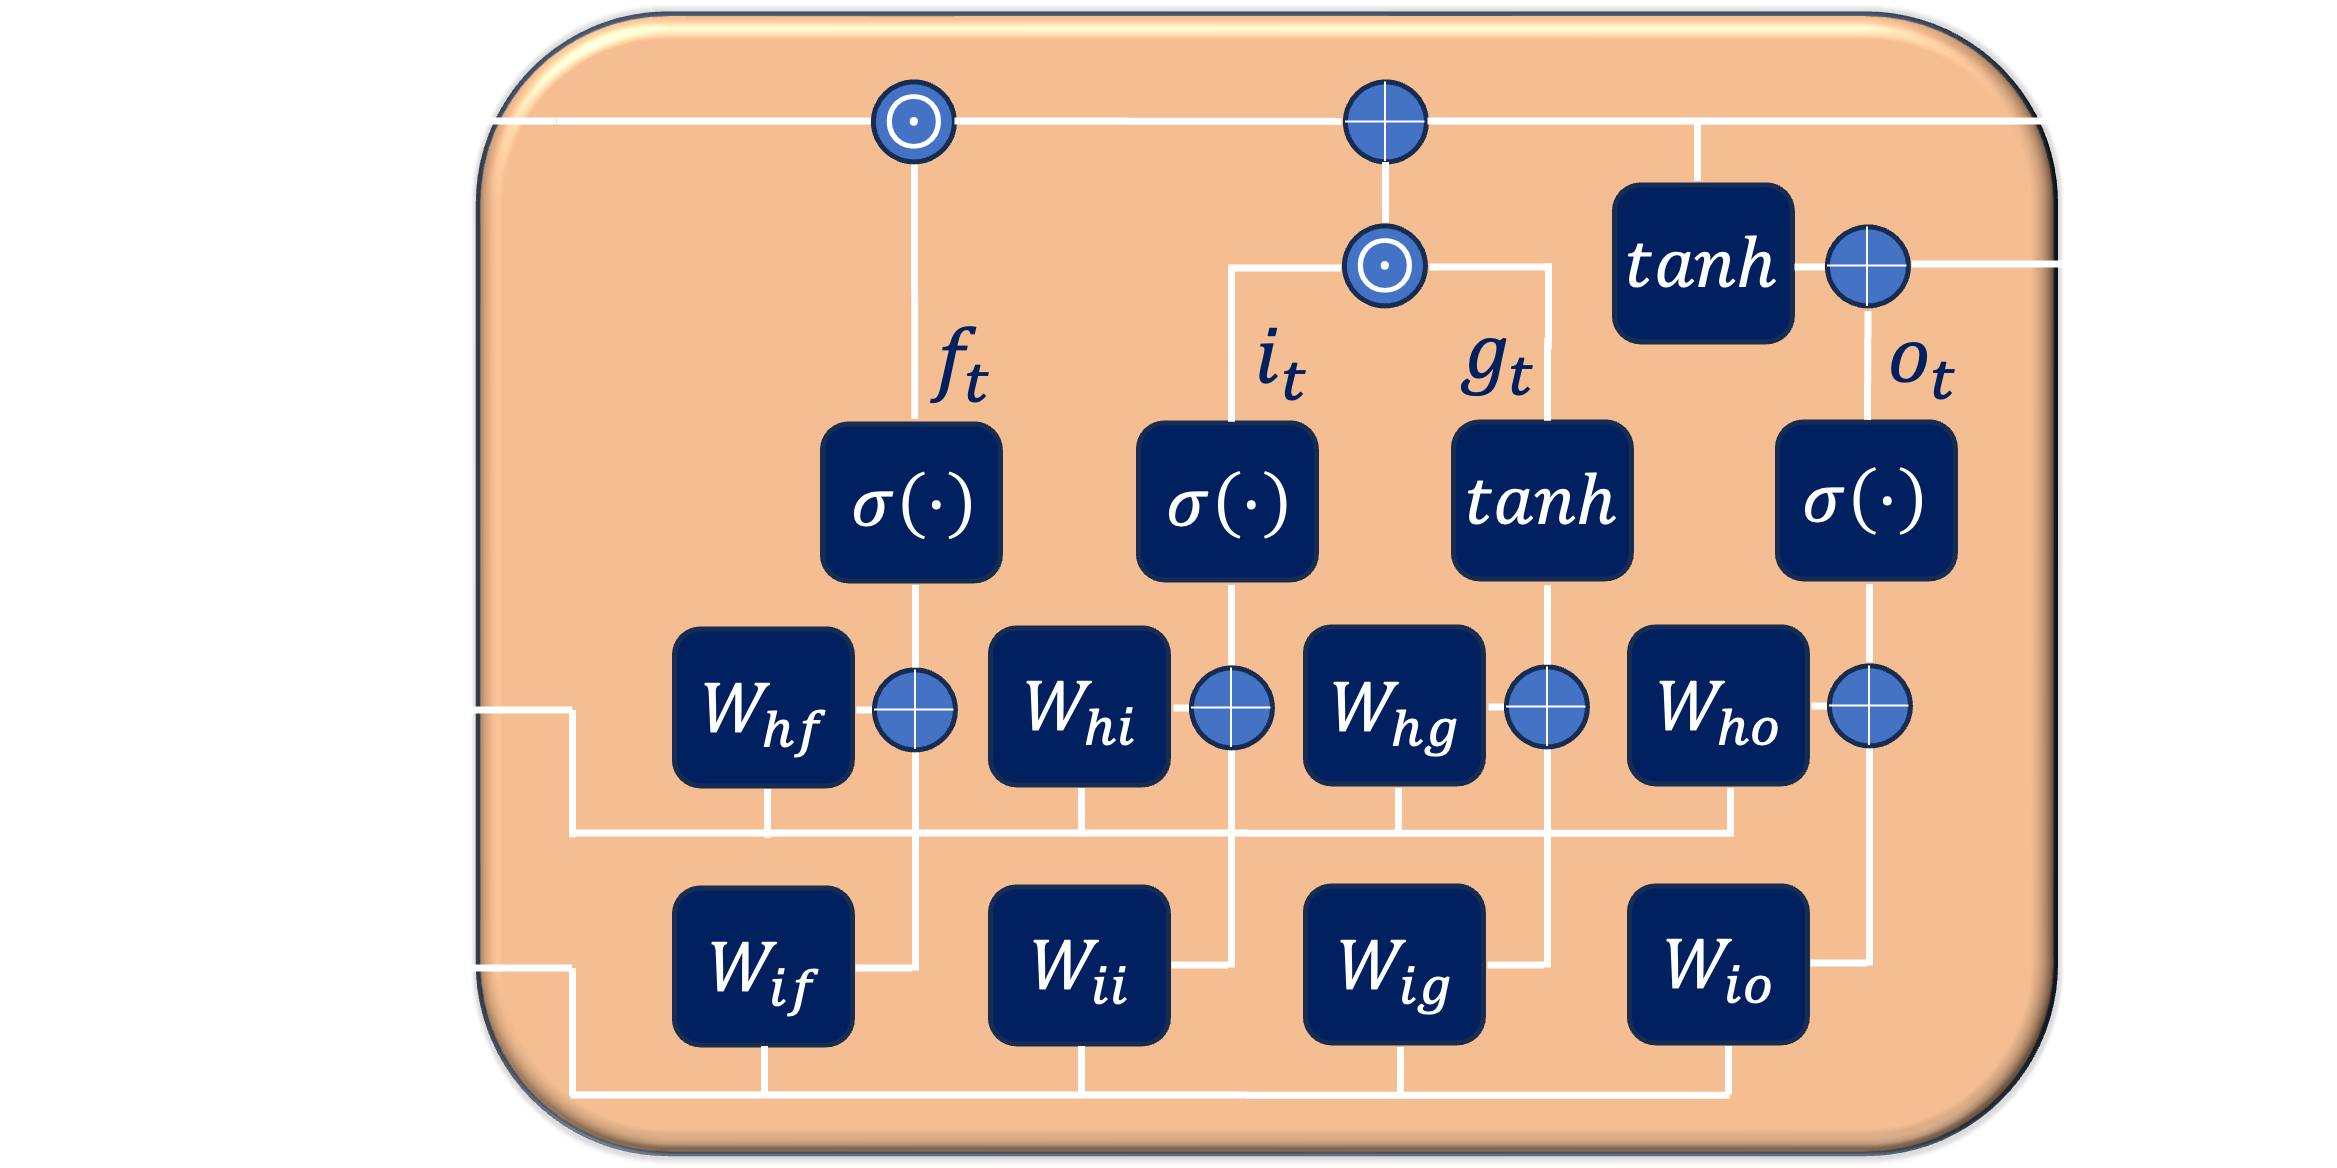

In [37]:
import torch
import torch.nn as nn

class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(EncoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        # We only care about the final hidden state (the Context Vector)
        _, hidden = self.lstm(embedded)
        return hidden # Shape: (num_layers, batch_size, hidden_dim)

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x is usually the very last word of the input sequence
        # to start the "prediction" phase
        embedded = self.embedding(x).unsqueeze(1) # Add seq_len dim
        output, hidden = self.lstm(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

class Seq2SeqNextWord(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqNextWord, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        # 1. Encode the input sequence into a context vector
        context_vector = self.encoder(x)

        # 2. For next-word prediction, the decoder needs a "starting word".
        # We typically use the last word of the input sequence (x[:, -1])
        start_token = x[:, -1]

        # 3. Decode the next word using the context vector
        prediction, _ = self.decoder(start_token, context_vector)

        return prediction

# --- Setup and Verification ---

vocabulary_size = 10000
embedding_dim = 64
hidden_size = 256

encoder = EncoderLSTM(vocabulary_size, embedding_dim, hidden_size)
decoder = DecoderLSTM(vocabulary_size, embedding_dim, hidden_size)
lstm_model = Seq2SeqNextWord(encoder, decoder).to(device)

print("Encoder-Decoder Model defined.")

# Verification with dummy data or your train_loader
example_batch_data = torch.randint(0, vocabulary_size, (32, 15)).to(device) # (batch, seq_len)

with torch.no_grad():
    sample_output = lstm_model(example_batch_data)

print(f"Input shape: {example_batch_data.shape}")
print(f"Output shape (Next Word Logits): {sample_output.shape}")

Encoder-Decoder Model defined.
Input shape: torch.Size([32, 15])
Output shape (Next Word Logits): torch.Size([32, 10000])


### **Training LSTM**

In [38]:
# Define Optimizer and Loss Function
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.")

# Set number of training epochs
num_epochs = 10 # You can adjust this value

# Call the training function
train_model(lstm_model, train_loader_15_words, optimizer, criterion, num_epochs)

Optimizer (Adam) and Criterion (CrossEntropyLoss) initialized.
Training on cuda
Epoch [1/10] completed.
Train Loss: 757.1541, Train Accuracy: 25.60%
--------------------------------------------------
Epoch [2/10] completed.
Train Loss: 680.7036, Train Accuracy: 31.08%
--------------------------------------------------
Epoch [3/10] completed.
Train Loss: 633.8102, Train Accuracy: 34.07%
--------------------------------------------------
Epoch [4/10] completed.
Train Loss: 595.1032, Train Accuracy: 36.71%
--------------------------------------------------
Epoch [5/10] completed.
Train Loss: 561.6229, Train Accuracy: 39.50%
--------------------------------------------------
Epoch [6/10] completed.
Train Loss: 531.1144, Train Accuracy: 42.54%
--------------------------------------------------
Epoch [7/10] completed.
Train Loss: 502.8452, Train Accuracy: 45.58%
--------------------------------------------------
Epoch [8/10] completed.
Train Loss: 475.7003, Train Accuracy: 48.67%
-----------

In [39]:
# Ensure the model is in evaluation mode
lstm_model.eval()

# Define the starting words
starting_words = ["I", "They", "Happy", "Movie", "Million"]

print("--- Generating next 9 words from a starting word ---")

generated_sequences = []
num_words_to_generate = 14 # We want to predict 9 words after the starting word

for start_word_str in starting_words:
    # Encode the starting word
    initial_word_idx = encode_word(start_word_str.lower(), word_index) # Convert to lowercase for consistent lookup
    current_sequence = [initial_word_idx]

    for _ in range(num_words_to_generate):
        # Convert current sequence to tensor, add batch dimension
        input_tensor = torch.tensor(current_sequence, dtype=torch.long).unsqueeze(0)

        # Move to the correct device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            output = lstm_model(input_tensor)

        # Get the predicted word index (the one with the highest probability)
        _, predicted_idx = torch.max(output, 1)

        # Append the predicted word's index to the current sequence
        current_sequence.append(predicted_idx.item())

    # Decode the entire generated sequence
    full_sequence_tensor = torch.tensor(current_sequence, dtype=torch.long)
    decoded_generated_sequence = decode_sequence_full(full_sequence_tensor)
    generated_sequences.append((start_word_str, decoded_generated_sequence))

for i, (start_word, generated_text) in enumerate(generated_sequences):
    print(f"Sequence {i+1} (started with '{start_word}'):")
    print(f"  '{generated_text}'")
    print("--------------------------------------------------")

--- Generating next 9 words from a starting word ---
Sequence 1 (started with 'I'):
  'i also found the idea how bad the director gets more than a brief shower'
--------------------------------------------------
Sequence 2 (started with 'They'):
  'they all seat for the film to make a good movie but it is a'
--------------------------------------------------
Sequence 3 (started with 'Happy'):
  'happy one of the old lady and the sequences are the only thing that they'
--------------------------------------------------
Sequence 4 (started with 'Movie'):
  'movie the only one who buys it it was made in the same way but'
--------------------------------------------------
Sequence 5 (started with 'Million'):
  'million the director thought i saw it for the first time i was in a'
--------------------------------------------------


### **Word Embedding Visualization**

UMAP plot of the word embeddings learned by your LSTM.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_25287/1458103254.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors


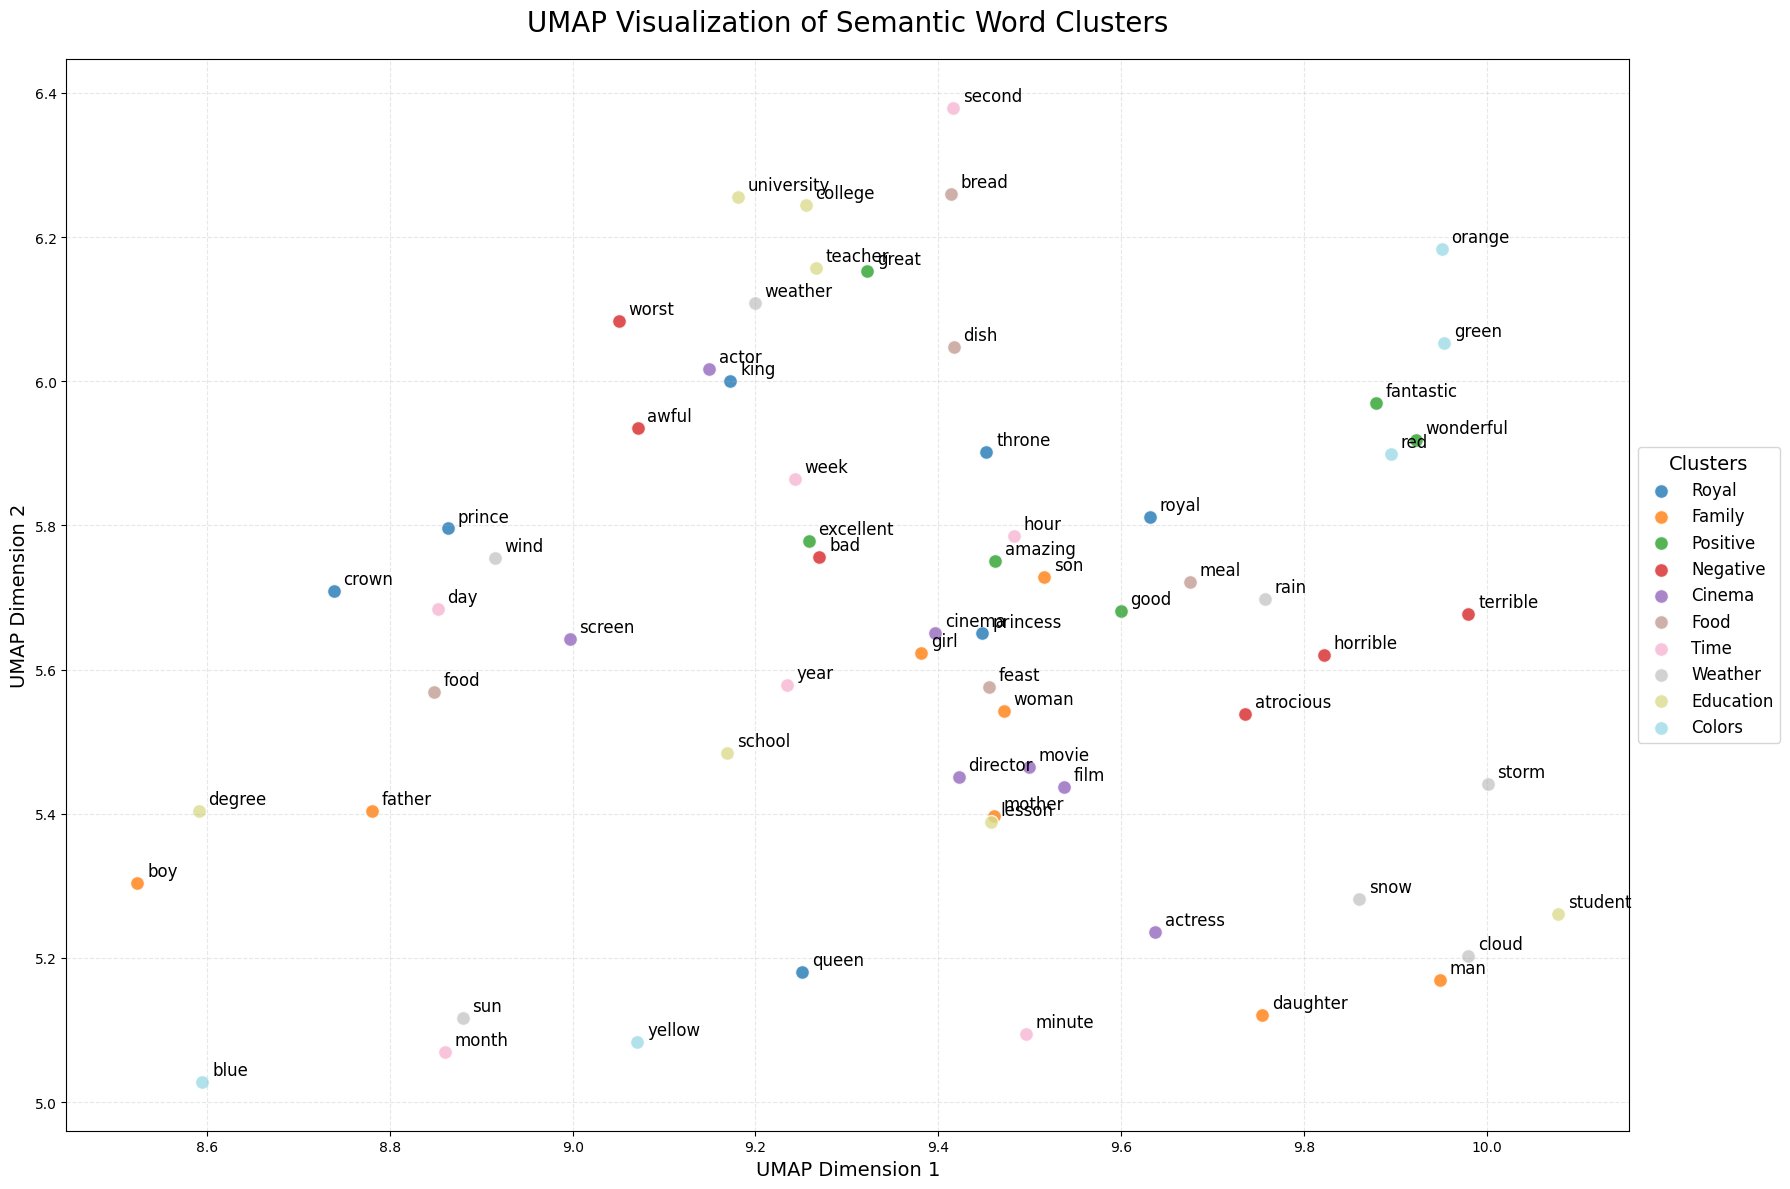

In [40]:
import matplotlib.pyplot as plt
import umap
import numpy as np
import torch

# 1. Setup Data Clusters
# Organized as a dictionary to easily assign colors/labels
clusters = {
    "Royal": ["king", "queen", "prince", "princess", "royal", "throne", "crown"],
    "Family": ["man", "woman", "boy", "girl", "father", "mother", "son", "daughter"],
    "Positive": ["good", "great", "excellent", "amazing", "wonderful", "fantastic"],
    "Negative": ["bad", "terrible", "awful", "horrible", "atrocious", "worst"],
    "Cinema": ["film", "movie", "cinema", "screen", "director", "actor", "actress"],
    "Food": ["bread", "meal", "food", "dish", "cuisine", "snack", "feast"],
    "Time": ["second", "minute", "hour", "day", "week", "month", "year"],
    "Weather": ["sun", "rain", "cloud", "storm", "wind", "snow", "weather"],
    "Education": ["school", "college", "university", "student", "teacher", "lesson", "degree"],
    "Colors": ["blue","red","orange","yellow","green"]
}

# 2. Extract Embeddings
selected_indices = []
selected_words = []
word_to_category = {}

for category, words in clusters.items():
    for word in words:
        original_idx = word_index.get(word, None)
        if original_idx is not None:
            shifted_idx = original_idx + 3
            if 4 <= shifted_idx < vocabulary_size:
                selected_indices.append(shifted_idx)
                selected_words.append(word)
                word_to_category[word] = category

if not selected_indices:
    print("No specified cluster words found in vocabulary.")
else:
    # Move model to CPU and get weights
    lstm_model.eval()
    word_embeddings = lstm_model.encoder.embedding.weight.data.cpu().numpy()
    selected_embeddings = np.array([word_embeddings[idx] for idx in selected_indices])

    # 3. Apply UMAP
    reducer = umap.UMAP(n_neighbors=7, min_dist=0.01, n_components=8, random_state=42)
    reduced_embeddings = reducer.fit_transform(selected_embeddings)

    # 4. Plotting
    plt.figure(figsize=(18, 12))

    # Use a colormap to get distinct colors for each category
    categories = list(clusters.keys())
    colors = plt.cm.get_cmap('tab20', len(categories)) # tab20 has 20 distinct colors
    category_to_color = {cat: colors(i) for i, cat in enumerate(categories)}

    # Track which categories we've added to the legend
    seen_categories = set()

    for i, word in enumerate(selected_words):
        x, y = reduced_embeddings[i, 0], reduced_embeddings[i, 1]
        category = word_to_category[word]

        # Plot point
        label = category if category not in seen_categories else None
        plt.scatter(x, y, color=category_to_color[category], s=100, label=label, edgecolors='white', alpha=0.8)
        seen_categories.add(category)

        # Annotate with larger font
        plt.annotate(
            word,
            (x, y),
            textcoords="offset points",
            xytext=(7, 5),
            ha='left',
            fontsize=12,  # Increased font size
            fontweight='medium'
        )

    plt.title('UMAP Visualization of Semantic Word Clusters', fontsize=20, pad=20)
    plt.xlabel('UMAP Dimension 1', fontsize=14)
    plt.ylabel('UMAP Dimension 2', fontsize=14)

    # Place legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, title="Clusters", title_fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Saliency**

Saliency is a technique used to visualize which parts of an input (like words in a sentence or pixels in an image) are most influential to a model's specific output. It acts as a "heat map" of the model's attention, helping us peek inside the "black box" of a neural network.

How it Works: The "Wiggle" Test
Saliency is powered by the same engine that trains the model: Backpropagation. Here is the step-by-step logic of how it is calculated:

1. The Forward Pass: You feed an input (e.g., the sentence "the car was blue") through the model to get a prediction (e.g., "shirt").

2. The Target Score: You pick the "score" (logit) for that specific prediction.

3. The Backward Pass: Instead of updating the model's weights (as you do during training), you keep the weights frozen. You calculate the gradient of the score with respect to the input itself.

Sensitivity Analysis: This gradient tells you: "If I 'wiggle' (change) this input word by a tiny amount, how much does the output score change?"

High Gradient: A small change in this word causes a huge change in the prediction. This word is salient.

Zero Gradient: You could change this word entirely, and the model's output wouldn't budge. This word is ignored.

### **RNN Saliency**

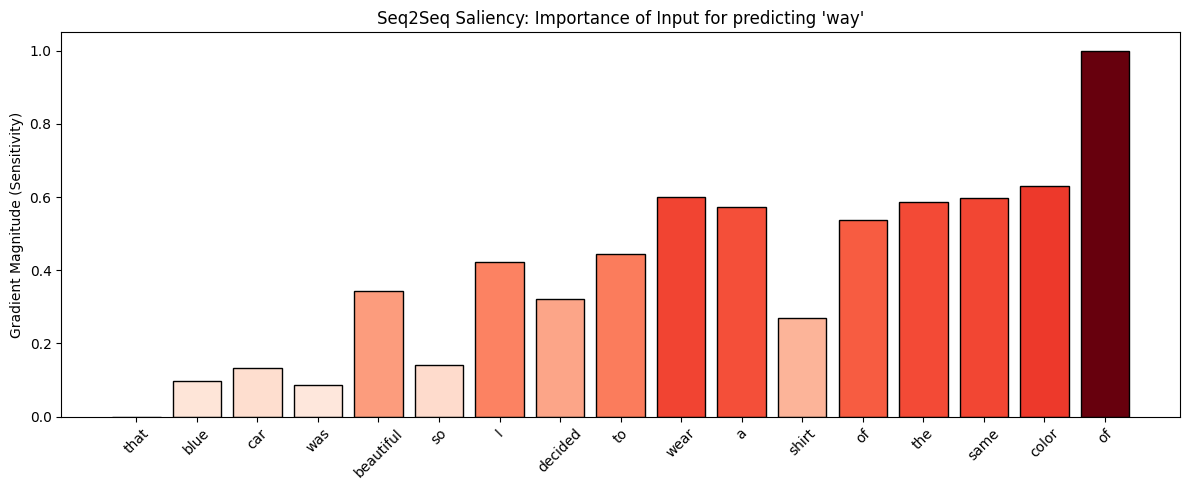

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_model_saliency(model, text_list, word_index_dict, decode_fn, device):
    # model.eval() # Recommended for stable saliency maps

    # 1. Prepare input indices
    input_indices = [word_index_dict.get(w.lower(), 2) for w in text_list]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).to(device).unsqueeze(0)

    # 2. Extract Encoder Embeddings manually to track gradients
    # We target model.encoder.embedding because the input starts there
    input_embeddings = model.encoder.embedding(input_tensor).detach()
    input_embeddings.requires_grad = True

    # 3. Forward Pass through the Encoder-Decoder architecture
    # We replicate the model's logic but use our tracked embeddings

    # Phase A: Encoding
    _, context_vector = model.encoder.rnn(input_embeddings)

    # Phase B: Decoding
    # The decoder typically starts with the last word of the input sequence
    start_token = input_tensor[:, -1]
    logits, _ = model.decoder(start_token, context_vector)

    # 4. Target the top prediction score
    score, idx = torch.max(logits, dim=-1)

    # 5. Backward Pass
    model.zero_grad()
    score.backward()

    # 6. Calculate Saliency
    # The gradient has now traveled through the Decoder back to the Encoder's input
    slc = input_embeddings.grad.data.abs().norm(dim=-1).squeeze()

    # Normalize for visualization (0 to 1)
    slc = (slc - slc.min()) / (slc.max() - slc.min() + 1e-8)
    slc = slc.cpu().numpy()

    # 7. Visualization
    predicted_word = decode_fn(idx.cpu().numpy())

    plt.figure(figsize=(12, 5))
    colors = plt.cm.Reds(slc)
    plt.bar(range(len(text_list)), slc, color=colors, edgecolor='black')
    plt.xticks(range(len(text_list)), text_list, rotation=45)
    plt.title(f"Seq2Seq Saliency: Importance of Input for predicting '{predicted_word}'")
    plt.ylabel("Gradient Magnitude (Sensitivity)")
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Ensure your model is on the correct device
sample_text = ["that","blue", "car", "was","beautiful","so", "I", "decided", "to", "wear", "a", "shirt", "of", "the", "same", "color","of"]
plot_model_saliency(rnn_model.train(), sample_text, word_index, decode_sequence_full, device)

### **GRU Saliency**

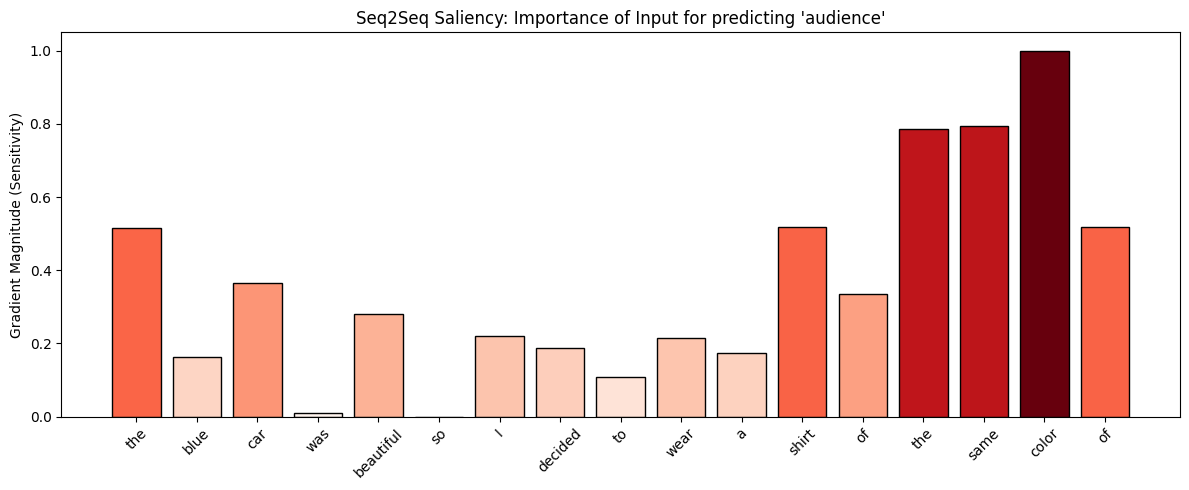

In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_model_saliency(model, text_list, word_index_dict, decode_fn, device):
    # model.eval() # Recommended for stable saliency maps

    # 1. Prepare input indices
    input_indices = [word_index_dict.get(w.lower(), 2) for w in text_list]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).to(device).unsqueeze(0)

    # 2. Extract Encoder Embeddings manually to track gradients
    # We target model.encoder.embedding because the input starts there
    input_embeddings = model.encoder.embedding(input_tensor).detach()
    input_embeddings.requires_grad = True

    # 3. Forward Pass through the Encoder-Decoder architecture
    # We replicate the model's logic but use our tracked embeddings

    # Phase A: Encoding
    _, context_vector = model.encoder.gru(input_embeddings)

    # Phase B: Decoding
    # The decoder typically starts with the last word of the input sequence
    start_token = input_tensor[:, -1]
    logits, _ = model.decoder(start_token, context_vector)

    # 4. Target the top prediction score
    score, idx = torch.max(logits, dim=-1)

    # 5. Backward Pass
    model.zero_grad()
    score.backward()

    # 6. Calculate Saliency
    # The gradient has now traveled through the Decoder back to the Encoder's input
    slc = input_embeddings.grad.data.abs().norm(dim=-1).squeeze()

    # Normalize for visualization (0 to 1)
    slc = (slc - slc.min()) / (slc.max() - slc.min() + 1e-8)
    slc = slc.cpu().numpy()

    # 7. Visualization
    predicted_word = decode_fn(idx.cpu().numpy())

    plt.figure(figsize=(12, 5))
    colors = plt.cm.Reds(slc)
    plt.bar(range(len(text_list)), slc, color=colors, edgecolor='black')
    plt.xticks(range(len(text_list)), text_list, rotation=45)
    plt.title(f"Seq2Seq Saliency: Importance of Input for predicting '{predicted_word}'")
    plt.ylabel("Gradient Magnitude (Sensitivity)")
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Ensure your model is on the correct device
sample_text = ["the","blue", "car", "was","beautiful","so", "I", "decided", "to", "wear", "a", "shirt", "of", "the", "same", "color","of"]
plot_model_saliency(gru_model.train(), sample_text, word_index, decode_sequence_full, device)